In [1]:
from datasets.fsmol_dock import FsDockDataset
from datasets.partitioned_fsmol_dock import FsDockDatasetPartitioned
# from visualize import make_fig
from datasets.process_chem.process_sidechains import add_frag_place_holder, get_core_and_chains, get_holes, get_mol_smiles



/home/alon.kitin/miniconda3/envs/FSdock/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/alon.kitin/miniconda3/envs/FSdock/lib/python3.9/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:

import torch


def mask_graph_sidechains(graph):
    device = graph['ligand'].x.device
    masks = {
        node_t:(
            (graph['ligand'].core_mask).to(device)
            if node_t == "ligand"
            else torch.arange(graph[node_t].num_nodes, device=device)
        )
        for node_t in graph.metadata()[0]
    }
    return graph.subgraph(masks)


In [3]:
# ds = FsDockDatasetPartitioned('data/fsdock/smol','data/fsdock/smol_tasks.csv', num_workers=torch.get_num_threads(), core_weight=0.7)
# ds.load()
from datasets.fsmol_dock_clf import FsDockClfDataset



In [4]:
import plotly.graph_objects as go

def add_frag_place_holder(graph):
    graph = graph.clone()
    frag_idxs = graph['ligand'].frag_idxs
    centers = []
    for i in range(graph['ligand'].frag_hole.shape[0]):
        mask = frag_idxs == i
        if mask.sum() == 0:
            continue
        center = graph['ligand'].pos[mask].mean(0, keepdim=True)
        centers.append(center)
    graph['frag'].pos = torch.cat(centers, dim=0)
    graph['frag'].x = torch.zeros(graph['frag'].pos.shape[0],1)
    graph['ligand','frag'].edge_index = torch.cat([graph['ligand'].frag_hole.unsqueeze(0), torch.arange(graph['ligand'].frag_hole.shape[0]).unsqueeze(0)], dim=0)
    #  edges
    for dst in ['atom', 'receptor']:
        edges = []
        for i in range(graph['ligand'].frag_hole.shape[0]):
            curr_frag_nodes = graph['ligand'].frag_idxs == i
            fe = graph['ligand',dst].edge_index
            fe = fe[:, curr_frag_nodes[fe[0]]]
            fe[0] = i
            edges.append(fe)
        if len(edges)>0:
            graph['frag', dst].edge_index = torch.cat(edges, dim=1)
            
            
    return graph
    
        
    
    
def plotly_edges(graph, start_l, end_l):
    start_pos = graph[start_l].pos
    end_pos = graph[end_l].pos
    edges = graph[start_l, end_l].edge_index
    xe=[]
    ye=[]
    ze=[]
    for s_pos, e_pos in zip(start_pos[edges[0]],end_pos[edges[1]]):
        xe+=[s_pos[0], e_pos[0], None]
        ye+=[s_pos[1], e_pos[1], None]
        ze+=[s_pos[2], e_pos[2], None]
    return {'x': xe, 'y':ye, 'z':ze, 'mode' : 'lines', 'name': f'{start_l}-{end_l}'}


def plotly_molecule_edges(graph):
    x =graph['ligand', 'ligand'].edge_attr.sum(1) !=0
    graph['ligand', 'ligand'].edge_index = graph['ligand', 'ligand'].edge_index[:,x]
    graph['ligand', 'ligand'].edge_attr = graph['ligand', 'ligand'].edge_attr[x,:]
    
    return plotly_edges(graph, 'ligand', 'ligand')
    

def plotly_nodes(graph,label):
    # _label = label if label!='frag' else 'ligand' 
    _label=label
    poses = graph[_label].pos
    xn=[]
    yn=[]
    zn=[]
    # poses = poses if label != 'frag' else poses[graph['ligand'].frag_idx]
    for pos in poses:
        xn.append(pos[0])
        yn.append(pos[1])
        zn.append(pos[2])
    return {'x': xn, 'y':yn, 'z':zn, 'mode': 'markers', 'name': _label}

def plotly_holes(graph):
    poses = graph['ligand'].pos
    xn=[]
    yn=[]
    zn=[]
    for pos in poses[graph['ligand'].frag_hole]:
        xn.append(pos[0])
        yn.append(pos[1])
        zn.append(pos[2])
    return {'x': xn, 'y':yn, 'z':zn, 'mode': 'markers', 'name': 'holes'}

def make_fig(graph) -> go.Figure:
    traces=[
        go.Scatter3d(**plotly_molecule_edges(graph), line=dict(color='red', width=4)),
        go.Scatter3d(**plotly_nodes(graph, 'ligand'), marker=dict(symbol='circle', size=5, color='blue')),
        go.Scatter3d(**plotly_nodes(graph, 'receptor'), marker=dict(symbol='circle', size=5, color='green')),
        go.Scatter3d(**plotly_nodes(graph, 'atom'), marker=dict(symbol='circle', size=5, color='orange')),
        go.Scatter3d(**plotly_edges(graph, 'atom', 'receptor'), line=dict(color='brown', width=0.3)),
        go.Scatter3d(**plotly_edges(graph, 'atom', 'atom'), line=dict(color='purple', width=0.3)),
        go.Scatter3d(**plotly_edges(graph, 'receptor', 'receptor'), line=dict(color='grey', width=1)),
        go.Scatter3d(**plotly_edges(graph, 'ligand', 'atom'), line=dict(color='light blue', width=0.3)),
        go.Scatter3d(**plotly_edges(graph, 'ligand', 'receptor'), line=dict(color='green', width=0.7)),
        go.Scatter3d(**plotly_holes(graph), marker=dict(symbol='circle', size=7, color='black')),
    ]
    if "frag" in graph.node_types:
        traces += [
            go.Scatter3d(**plotly_nodes(graph, 'frag'), marker=dict(symbol='cross', size=5, color='grey')),
            go.Scatter3d(**plotly_edges(graph, 'frag', 'atom'), line=dict(color='grey', width=0.3)),
            go.Scatter3d(**plotly_edges(graph, 'frag', 'receptor'), line=dict(color='dark grey', width=0.7)),
        ]
        
   
    fig = go.Figure(data=traces, layout=go.Layout(
        template='simple_white',
    width=800,
    height=800
        ))
    return fig

In [5]:

def mask_edges_between(graph, src_key,dst_key):
    edge_index = graph[src_key, dst_key].edge_index
    frag_mask = ~graph['ligand'].core_mask
    if src_key == dst_key and src_key == "ligand":
        mask = frag_mask[edge_index]
        mask = (mask[0] | mask[1]) # one of the nodes is in fragment
    else:
        # mask edges that start at sidechains and connect to the protein
        mask = frag_mask[edge_index[0]]
    edge_index = edge_index[:,~mask]
    graph[src_key, dst_key].edge_index = edge_index
    if "edge_attr" in graph[src_key, dst_key]:
        edge_attr = graph[src_key, dst_key].edge_attr
        edge_attr = edge_attr[~mask]
        graph[src_key, dst_key].edge_attr = edge_attr

def mask_fragments(graph):
    mask_edges_between(graph, "ligand", "ligand")
    mask_edges_between(graph, "ligand", "receptor")
    mask_edges_between(graph, "ligand", "atom")
    return graph


In [8]:
# ds = FsDockDataset('data/cross/test','data/cross/test_tasks.csv', num_workers=torch.get_num_threads(), core_weight=0.7, ligand_radius=10)
# ds2 = FsDockDataset('data/cross/test2','data/cross/test_tasks.csv', num_workers=torch.get_num_threads(), core_weight=0.7, ligand_radius=10)
ds.random_translation=8
# ds.ligand_radius=15
graph = ds[46]
make_fig((graph))


In [7]:
graph = ds[46]
print(graph['ligand'].frag_smiles, ds2[46]['ligand'].frag_smiles)
print(graph['ligand'].core_smiles==ds2[46]['ligand'].core_smiles)
print(graph['ligand'].smiles==ds2[46]['ligand'].smiles)

NameError: name 'ds2' is not defined

In [ ]:
from datasets.process_chem.process_sidechains import get_core_and_chains, reconstruct_from_core_and_chains, Chem
print(graph['ligand'].core_smiles, '.'.join([f'[{i+1}*]{s}' for i,s in enumerate(graph['ligand'].frag_smiles)]))
print(reconstruct_from_core_and_chains(graph['ligand'].core_smiles, '.'.join([f'[{i+1}*]{s}' for i,s in enumerate(graph['ligand'].frag_smiles)])))
print(graph['ligand'].smiles)


[1*][C@H]1O[C@@H](n2cnc3c([5*])nc([4*])nc32)[C@H]([3*])[C@@H]1[2*] [1*]CO[P@](=O)(O)OP(=O)(O)O.[2*]O.[3*]O.[4*]SC.[5*]N
CSc1nc(N)c2ncn(C3OC(COP(=O)(O)OP(=O)(O)O)C(O)C3O)c2n1
CSc1nc(N)c2ncn([C@@H]3O[C@H](CO[P@](=O)(O)OP(=O)(O)O)[C@@H](O)[C@H]3O)c2n1


In [ ]:
len(ds)

83

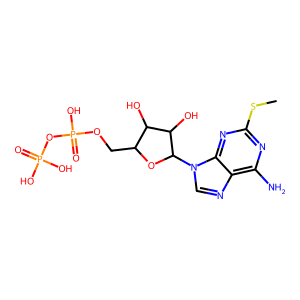

In [ ]:
mol = Chem.MolFromSmiles('CSc1nc(N)c2ncn(C3OC(COP(=O)(O)OP(=O)(O)O)C(O)C3O)c2n1')
mol = Chem.MolFromSmiles('CSc1nc(N)c2ncn([C@@H]3O[C@H](CO[P@](=O)(O)OP(=O)(O)O)[C@@H](O)[C@H]3O)c2n1')
mol = Chem.MolFromSmiles('CSc1nc(N)c2ncn(C3OC(COP(=O)(O)OP(=O)(O)O)C(O)C3O)c2n1')
#draw mol
from rdkit.Chem import Draw
Draw.MolToImage(mol)


In [ ]:
sdf_mol_file = '/home/alon.kitin/pmdm/crossdocked_pocket10/P2Y12_HUMAN_1_342_0/4pxz_A_rec_4pxz_6ad_lig_tt_min_0.sdf'
g = Chem.SDMolSupplier(sdf_mol_file)[0]

get_core_and_chains(g,0.7)[-1]['core_smiles']

'[1*][C@H]1O[C@@H](n2cnc3c([5*])nc([4*])nc32)[C@H]([3*])[C@@H]1[2*]'

In [ ]:
get_core_and_chains(Chem.MolFromSmiles(Chem.MolToSmiles(g)),0.7)[-1]['core_smiles']
# Chem.MolToSmiles(g)
# Chem.MolFromSmiles(Chem.MolToSmiles(g))
print(get_core_and_chains(g,0.7)[-1])
print(get_core_and_chains(Chem.MolFromSmiles(Chem.MolToSmiles(g)),0.7)[-1])

{'core_mask': array([ True,  True,  True, False,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False]), 'hole_count': array([1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0]), 'frag_idxs': array([-1, -1, -1,  0, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  2,
        3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4]), 'frag_hole': array([ 2,  4, 15, 13,  0]), 'num_frags': 5, 'core_smiles': '[1*][C@H]1O[C@@H](n2cnc3c([5*])nc([4*])nc32)[C@H]([3*])[C@@H]1[2*]', 'frag_smiles': ['O', 'O', 'N', 'SC', 'CO[P@](=O)(O)OP(=O)(O)O']}
{'core_mask': array([False, False,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False,  True, False,  True, False,
        True,  True]), 'hole_count': array([0, 0, 1, 0, 1, 

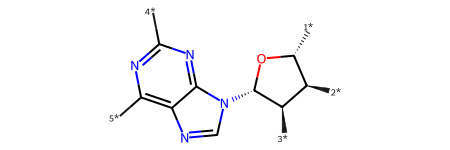

In [ ]:
Chem.MolFromSmiles('[1*][C@H]1O[C@@H](n2cnc3c([5*])nc([4*])nc32)[C@H]([3*])[C@@H]1[2*]')

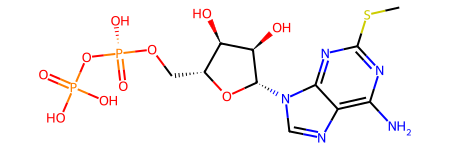

In [ ]:
Chem.MolFromSmiles('CSc1nc(N)c2ncn([C@@H]3O[C@H](CO[P@](=O)(O)OP(=O)(O)O)[C@@H](O)[C@H]3O)c2n1')

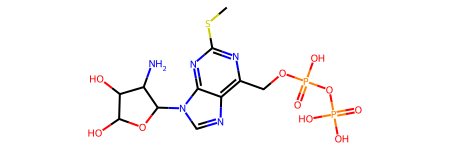

In [ ]:
Chem.MolFromSmiles('CSc1nc(COP(=O)(O)OP(=O)(O)O)c2ncn(C3OC(O)C(O)C3N)c2n1')

In [ ]:
ligand = Chem.MolFromSmiles('CSc1nc(N)c2ncn([C@@H]3O[C@H](CO[P@](=O)(O)OP(=O)(O)O)[C@@H](O)[C@H]3O)c2n1')
core, sidechains, data = get_core_and_chains(ligand,0.7)
data

{'core_mask': array([False, False,  True,  True,  True, False,  True,  True,  True,
         True,  True,  True,  True, False, False, False, False, False,
        False, False, False, False, False,  True, False,  True, False,
         True,  True]),
 'hole_count': array([0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 1, 0, 0, 0]),
 'frag_idxs': array([ 0,  0, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2, -1,  3, -1,  4, -1, -1]),
 'frag_hole': array([ 2,  4, 12, 23, 25]),
 'num_frags': 5,
 'core_smiles': '[1*]c1nc([2*])c2ncn([C@@H]3O[C@H]([3*])[C@@H]([4*])[C@H]3[5*])c2n1',
 'frag_smiles': ['SC', 'N', 'CO[P@](=O)(O)OP(=O)(O)O', 'O', 'O']}

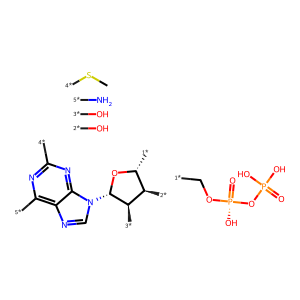

In [ ]:
mol = Chem.MolFromSmiles('[1*][C@H]1O[C@@H](n2cnc3c([5*])nc([4*])nc32)[C@H]([3*])[C@@H]1[2*].[2*]O.[3*]O.[5*]N.[4*]SC.[1*]CO[P@](=O)(O)OP(=O)(O)O')
# Chem.MolFromSmiles('CSc1nc(N)c2ncn([C@@H]3O[C@H](CO[P@](=O)(O)OP(=O)(O)O)[C@@H](O)[C@H]3O)c2n1')
#draw mol
from rdkit.Chem import Draw
Draw.MolToImage(mol)


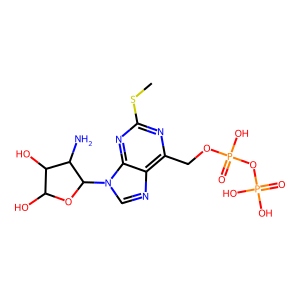

In [ ]:

mol = Chem.MolFromSmiles('CSc1nc(N)c2ncn([C@@H]3O[C@H](CO[P@](=O)(O)OP(=O)(O)O)[C@@H](O)[C@H]3O)c2n1')
mol = Chem.MolFromSmiles('CSc1nc(COP(=O)(O)OP(=O)(O)O)c2ncn(C3OC(O)C(O)C3N)c2n1')
#draw mol
Draw.MolToImage(mol)
